# Synthetic Data Experiment Series

## 01 - Cylindrical Mixture

This notebook samples synthetic data from a **mixture of Cylindrical distributions** (`d_gauss=3`, `d_vmf=3`).

Then compares a mixture of Cylindrical and a mixture-of-mixtures perfomances in learning such data.

**Note:** An extensive grid-search (```01_cylindrical_mixture_extensive.py```) was run before to narrow down the grid-search in this didactic notebook.

In [61]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd

%matplotlib widget
import soccer_pattern_recognition as spr
from experiment.synthetic_data import experiment_helper as mod


rng = np.random.RandomState(7)
D_GAUSS = mod.D_GAUSS
D_VMF = mod.D_VMF
N = 10000

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Data Generation

In [62]:
def unit(v):
    v = np.asarray(v, dtype=float)
    if v.ndim == 1:
        norm = np.linalg.norm(v)
        return v / max(norm, 1e-12)
    else:
        norm = np.linalg.norm(v, axis=-1, keepdims=True)
        return v / np.clip(norm, 1e-12, None)

In [63]:
# Mixture of Cylindrical distributions (d=3, d=3)
cyl_components = [
    spr.Cylindrical(
        D_GAUSS, D_VMF,
        mu_gauss=np.array([0.0, 0.0, 0.0]),
        cross_cov=np.array([[ 0.45, -0.10,  0.20],
                            [ 0.05,  0.30, -0.15],
                            [-0.25,  0.10,  0.35]]),
        cond_cov=np.array([[2.20, 0.75, 0.40],
                           [0.75, 0.55, 0.10],
                           [0.40, 0.10, 0.25]]),
        mu_vmf=unit([1.0, 0.0, 0.0]),
        kappa=9.0,
    ),

    spr.Cylindrical(
        D_GAUSS, D_VMF,
        mu_gauss=np.array([0.0, 0.0, 0.0]),   # same Gaussian mean
        cross_cov=np.array([[-0.30,  0.20,  0.10],
                            [ 0.15, -0.25,  0.05],
                            [ 0.10,  0.05, -0.20]]),
        cond_cov=np.array([[0.75, 0.05, 0.00],
                           [0.05, 0.85, 0.08],
                           [0.00, 0.08, 0.70]]),   # much more isotropic
        mu_vmf=unit([0.0, 1.0, 0.0]),
        kappa=9.0,
    ),

    spr.Cylindrical(
        D_GAUSS, D_VMF,
        mu_gauss=np.array([2.3, 1.2, -1.0]),
        cross_cov=np.array([[ 0.10,  0.15, -0.20],
                            [-0.05,  0.25,  0.18],
                            [ 0.20, -0.10,  0.12]]),
        cond_cov=np.array([[0.95, 0.18, -0.05],
                           [0.18, 1.05, 0.12],
                           [-0.05, 0.12, 0.80]]),
        mu_vmf=unit([0.0, 0.0, 1.0]),
        kappa=5.5,
    ),
]

cyl_weights = np.array([0.35, 0.35, 0.30], dtype=float)

generator = spr.MixtureModel(components=cyl_components,
                               weights=cyl_weights,
                               init="k-means",
                               rng=rng)

x = generator.sample(N, rng=rng)

In [64]:
x_gauss = x[:, :D_GAUSS]
x_vmf = x[:, D_GAUSS:]

In [65]:
# medium noise setup
sigma_g = 0.15 * np.maximum(x_gauss.std(axis=0, ddof=1), 1e-8)
sigma_v = 0.05

noise_g = rng.normal(0.0, sigma_g, size=(N, D_GAUSS))
noise_v = rng.normal(0.0, sigma_v, size=(N, D_VMF))

x_noisy_gauss = noise_g + x_gauss
x_noisy_vmf = noise_v + x_vmf

# re-project directional block to unit sphere (required for vMF)
x_noisy_vmf = unit(x_noisy_vmf)
x_noisy = np.concatenate((x_noisy_gauss, x_noisy_vmf), axis=1)

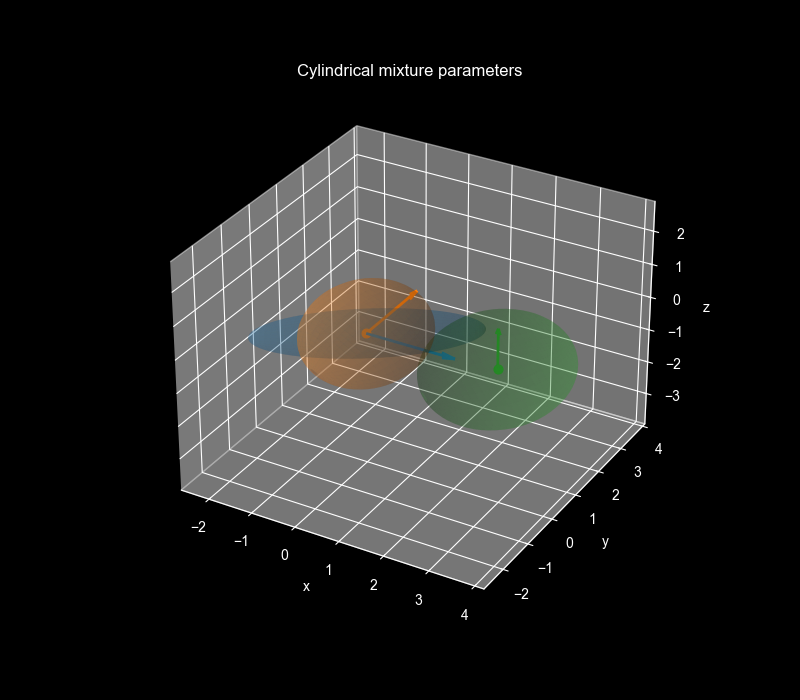

In [66]:
fig, ax = mod.plot_cylindrical_components(generator, arrow_scale=2.0)

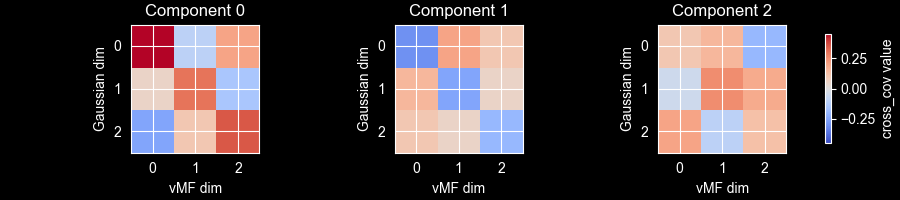

In [67]:
mod.plot_cross_cov_matrices(generator.components, cmap="coolwarm")

### Model Training

**1) Mixture of Cylindrical distributions**

In [68]:
cyl_mixture = mod.cylindrical_mixture_builder_3d(
    n_components=3,
    init="k-means",
    rng=np.random.RandomState(42)
)
cyl_mixture.fit(x)
print("n iteration:", cyl_mixture.n_iter)

n iteration: 6


In [69]:
noisy_cyl_mixture = mod.cylindrical_mixture_builder_3d(
    n_components=3,
    init="k-means",
    rng=np.random.RandomState(42)
)
noisy_cyl_mixture.fit(x_noisy)
print("n iteration:", noisy_cyl_mixture.n_iter)

n iteration: 6


**2) Mixture of Independent Cylindrical distributions**

Selected by Elbow heuristic rather than best score.

In [70]:
indcyl_mixture = mod.ind_cylindrical_mixture_builder_3d(
    n_components=3,
    init="k-means",
    rng=np.random.RandomState(42)
)
indcyl_mixture.fit(x)
print("n iteration:", indcyl_mixture.n_iter)

n iteration: 11


In [71]:
noisy_indcyl_mixture = mod.ind_cylindrical_mixture_builder_3d(
    n_components=3,
    init="k-means",
    rng=np.random.RandomState(42)
)
noisy_indcyl_mixture.fit(x_noisy)
print("n iteration:", noisy_indcyl_mixture.n_iter)

n iteration: 11


**3) Two-Layer Hierarchical Mixture**

Selected by best score.

In [72]:
mom = mod.mom_builder_3d(
    n_layer1_components=6,
    n_layer2_components=1,
    init_layer1="k-means",
    init_layer2="k-means",
    rng=np.random.RandomState(42)
)
mom.fit(x_gauss, x_vmf)
print("n iteration:", mom.n_iter)

n iteration: 35


In [73]:
noisy_mom = mod.mom_builder_3d(
    n_layer1_components=6,
    n_layer2_components=2,
    init_layer1="k-means",
    init_layer2="k-means",
    rng=np.random.RandomState(42)
)
noisy_mom.fit(x_noisy_gauss, x_noisy_vmf)
print("n iteration:", noisy_mom.n_iter)

n iteration: 36


**4) Isolated-in-training Two-layer Hierarchical Mixture**

In [74]:
iso_mom = mod.mom_iso_builder_3d(
    n_layer1_components=3,
    n_layer2_components=3,
    init_layer1="k-means",
    init_layer2="k-means",
    rng=np.random.RandomState(42)
)
iso_mom.fit(x_gauss, x_vmf)
print("n iteration:", iso_mom.n_iter)

n iteration: 54


In [75]:
noisy_iso_mom = mod.mom_iso_builder_3d(
    n_layer1_components=3,
    n_layer2_components=3,
    init_layer1="k-means",
    init_layer2="k-means",
    rng=np.random.RandomState(42)
)
noisy_iso_mom.fit(x_noisy_gauss, x_noisy_vmf)
print("n iteration:", noisy_iso_mom.n_iter)

n iteration: 53


### Model Comparison


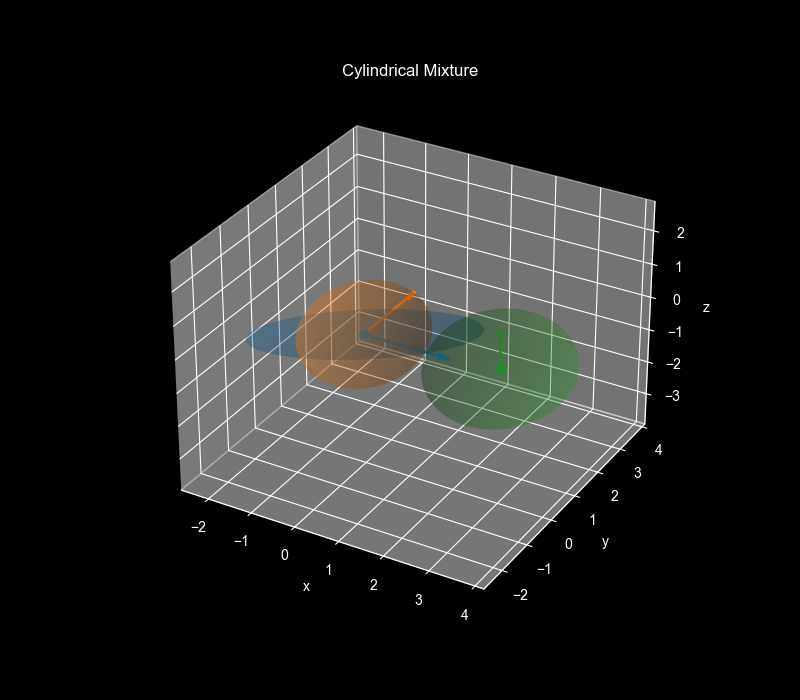

In [76]:
fig, ax = mod.plot_cylindrical_components(cyl_mixture, arrow_scale=2.0,
                                          title=f"Cylindrical Mixture")

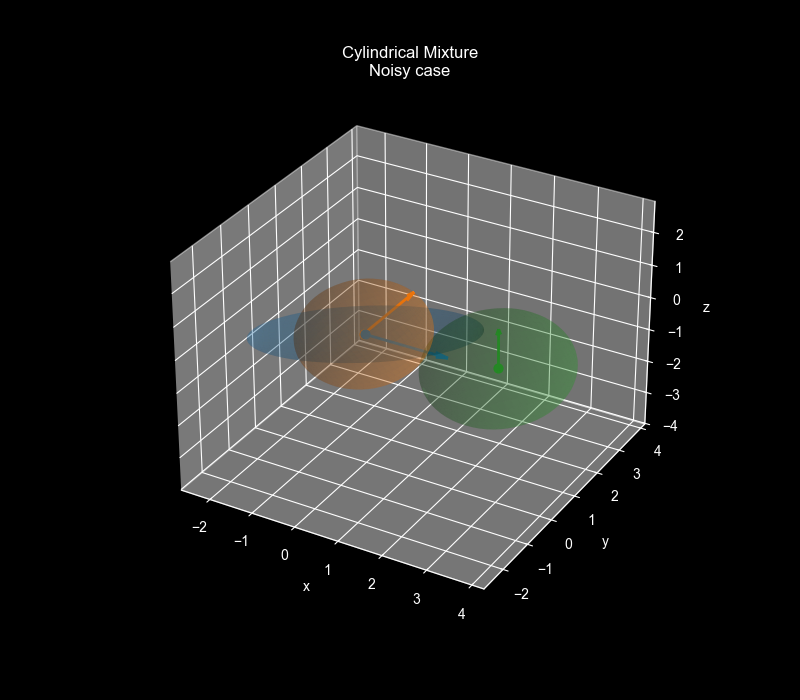

In [77]:
fig, ax = mod.plot_cylindrical_components(noisy_cyl_mixture, arrow_scale=2.0,
                                          title=f"Cylindrical Mixture\nNoisy case")

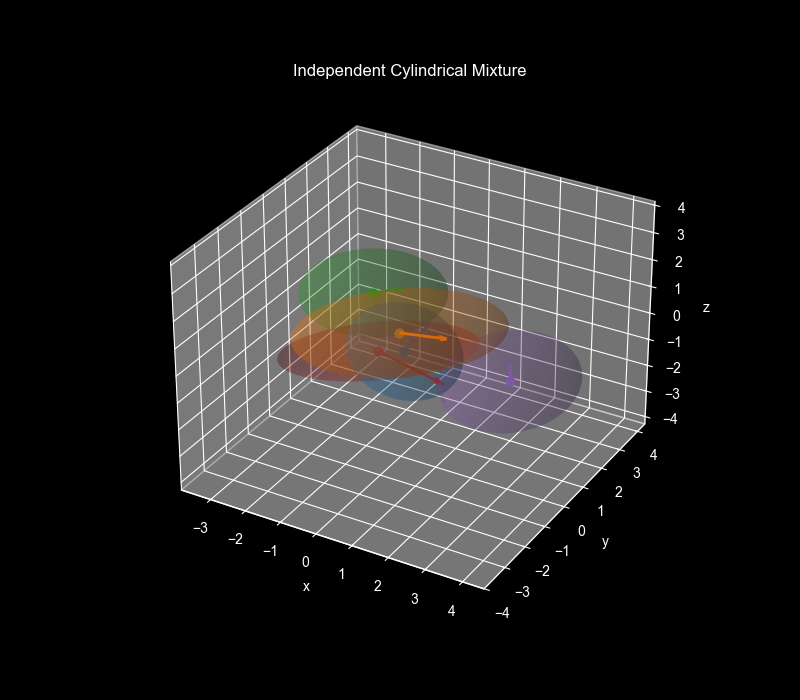

In [78]:
fig, ax = mod.plot_cylindrical_components(indcyl_mixture, arrow_scale=2.0,
                                          title="Independent Cylindrical Mixture")

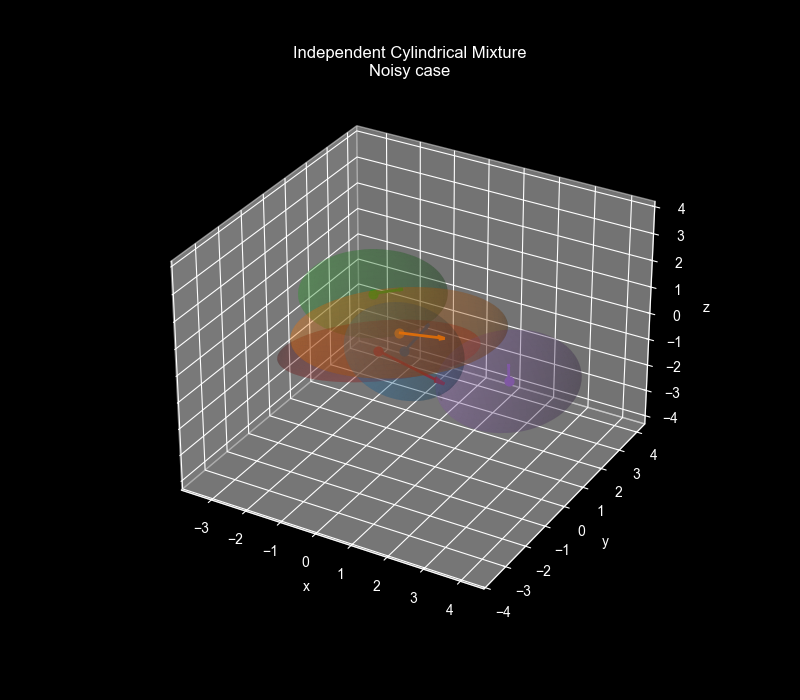

In [79]:
fig, ax = mod.plot_cylindrical_components(noisy_indcyl_mixture, arrow_scale=2.0,
                                          title=f"Independent Cylindrical Mixture\nNoisy case")

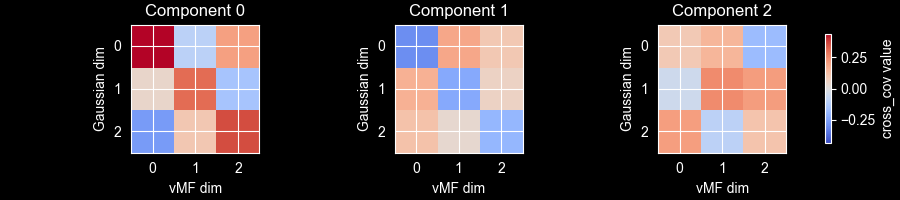

In [80]:
mod.plot_cross_cov_matrices(cyl_mixture.components, cmap="coolwarm")

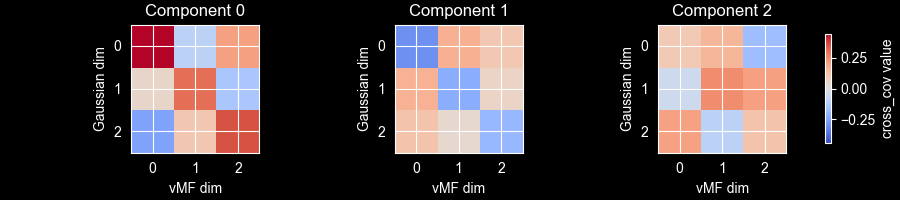

In [81]:
mod.plot_cross_cov_matrices(noisy_cyl_mixture.components, cmap="coolwarm")

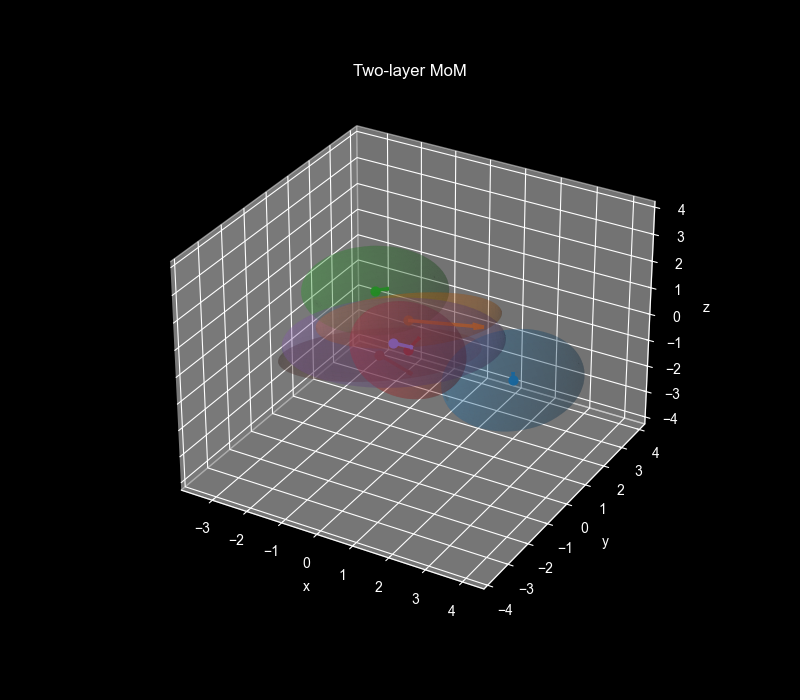

In [82]:
fig, ax = mod.plot_mom_components(mom, arrow_scale=2.0,
                                  title=f"Two-layer MoM")

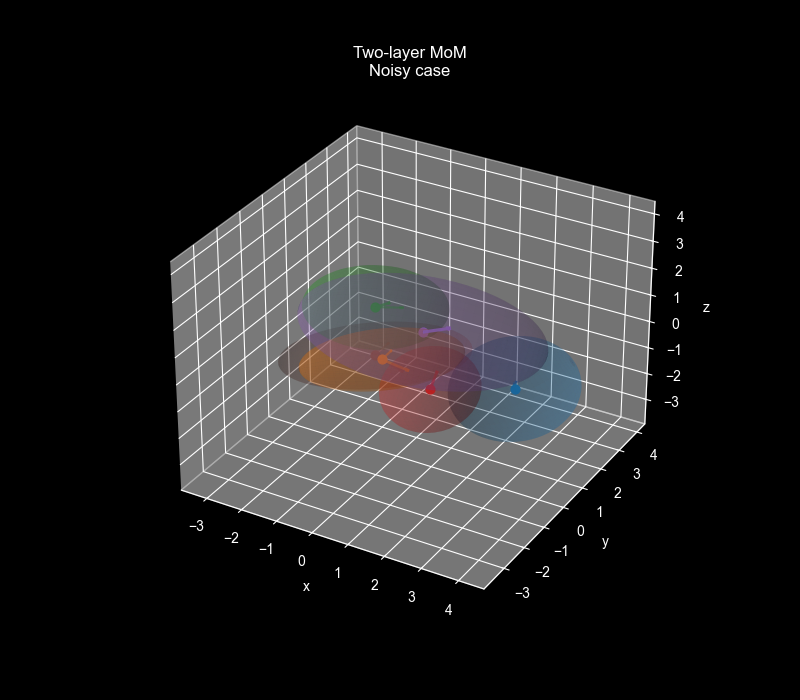

In [83]:
fig, ax = mod.plot_mom_components(noisy_mom, arrow_scale=2.0,
                                  title=f"Two-layer MoM\nNoisy case")

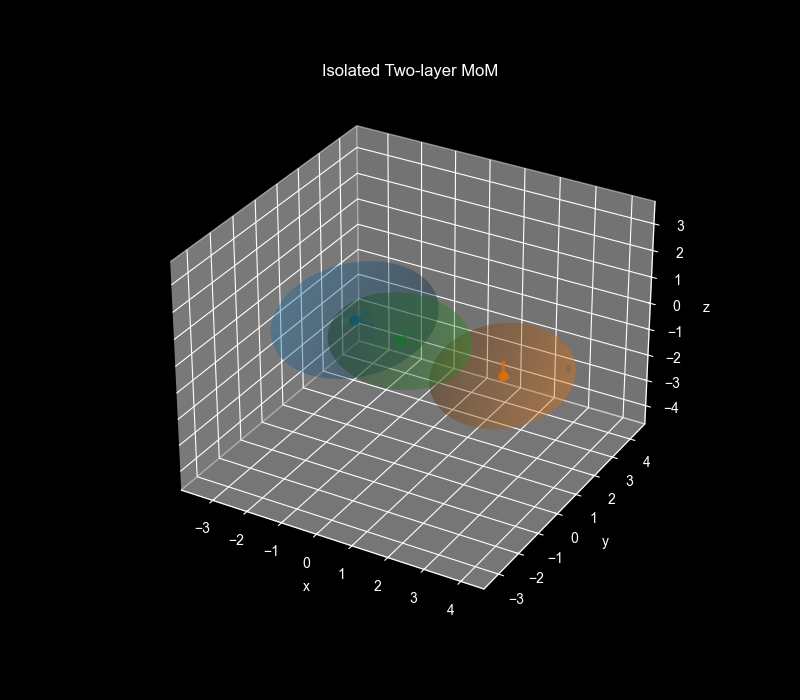

In [84]:
fig, ax = mod.plot_mom_components(iso_mom, arrow_scale=2.0,
                                  title=f"Isolated Two-layer MoM")

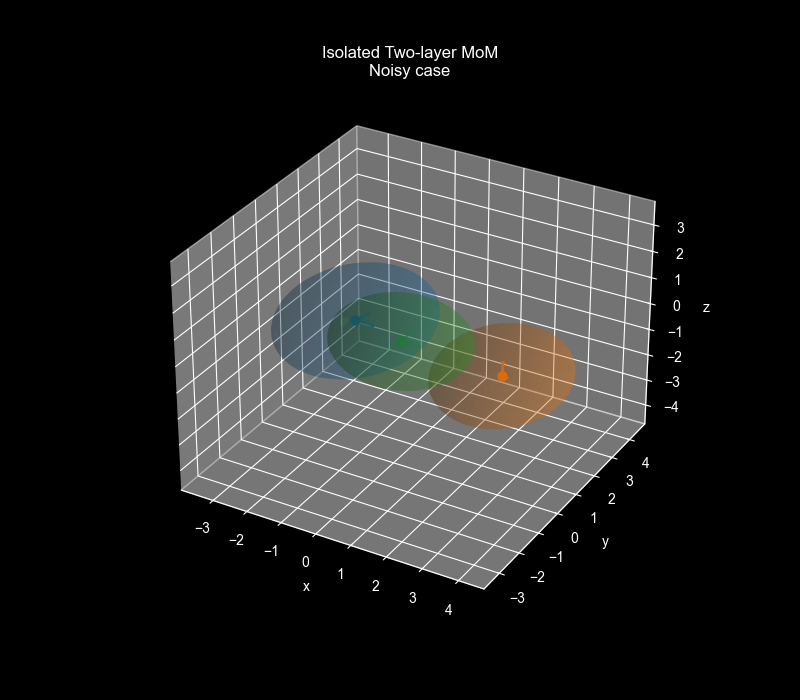

In [85]:
fig, ax = mod.plot_mom_components(noisy_iso_mom, arrow_scale=2.0,
                                  title=f"Isolated Two-layer MoM\nNoisy case")

In [86]:
import pandas as pd

rows = []

def add_case(case_name, x_mix, xg_mom, xv_mom):
    rows.extend([
        {"case": case_name,
            "model": "Cylindrical Mixture",
            "bic": cyl_mixture.bic_score(x_mix),
            "neg_ll": -cyl_mixture.log_pdf(x_mix).sum()},
        {"case": case_name,
            "model": "Ind. Cylindrical Mixture",
            "bic": indcyl_mixture.bic_score(x_mix),
            "neg_ll": -indcyl_mixture.log_pdf(x_mix).sum()},
        {"case": case_name,
            "model": "Two-layer MoM",
            "bic": mom.bic_score(xg_mom, xv_mom),
            "neg_ll": -mom.log_pdf(xg_mom, xv_mom).sum()},
        {"case": case_name,
            "model": "Isolated Two-layer MoM",
            "bic": iso_mom.bic_score(xg_mom, xv_mom),
            "neg_ll": -iso_mom.log_pdf(xg_mom, xv_mom).sum()},
    ])

add_case("Pure signal", x, x_gauss, x_vmf)
add_case("Noisy", x_noisy, x_noisy_gauss, x_noisy_vmf)

df_scores = pd.DataFrame(rows)
df_scores[["bic", "neg_ll"]] = df_scores[["bic", "neg_ll"]].round(0).astype(int)
df_scores

,case,model,bic,neg_ll
0,Pure signal,Cylindrical Mixture,110867,55134
1,Pure signal,Ind. Cylindrical Mixture,125105,62258
2,Pure signal,Two-layer MoM,123713,61502
3,Pure signal,Isolated Two-layer MoM,131321,65375
4,Noisy,Cylindrical Mixture,114779,57090
5,Noisy,Ind. Cylindrical Mixture,126727,63069
6,Noisy,Two-layer MoM,125418,62354
7,Noisy,Isolated Two-layer MoM,132479,65954
